In [1]:
import yfinance as yf

# Hämta candle-data (High/Low/Open/Close per timme) för guld, senaste 5 dagarna
# Byt ut GC=F mot t.ex. EURUSD=X om man vill kolla FVG för Eur/USD
data = yf.download("GC=F", period="5d", interval="1h")
data.columns = data.columns.get_level_values(0)
print(data)

[*********************100%***********************]  1 of 1 completed

Price                            Close         High          Low         Open  \
Datetime                                                                        
2026-09-20 18:00:00-04:00  4412.100098  4417.799805  4412.000000  4415.000000   
2026-09-20 19:00:00-04:00  4411.600098  4414.799805  4406.899902  4412.200195   
2026-09-20 20:00:00-04:00  4404.799805  4414.299805  4396.399902  4411.500000   
2026-09-20 21:00:00-04:00  4415.700195  4422.100098  4404.799805  4404.799805   
2026-09-20 22:00:00-04:00  4401.500000  4416.200195  4399.000000  4416.000000   
...                                ...          ...          ...          ...   
2026-09-24 05:00:00-04:00  4289.700195  4301.700195  4285.000000  4295.500000   
2026-09-24 06:00:00-04:00  4292.500000  4299.399902  4278.299805  4289.600098   
2026-09-24 07:00:00-04:00  4300.399902  4302.399902  4286.399902  4292.399902   
2026-09-24 08:00:00-04:00  4316.000000  4318.200195  4295.000000  4300.200195   
2026-09-24 09:00:00-04:00  4

In [2]:
def bullish_fvg(data):
    # Plocka ut alla High- och Low-priser som två separata listor
    highs = data['High'].values
    lows = data['Low'].values
    resultat = []
    
    for i in range(2, len(data)):                                   # Gå igenom candlarna en i taget, börja på nummer 3 (index 2)
        if lows[i] > highs[i-2]:                                    # Är lägstapriset här HÖGRE än högstapriset två candles tidigare = FVG
            resultat.append((data.index[i], highs[i-2], lows[i]))   # Spara datum, var FVG börjar och var det slutar
    return resultat

In [3]:
fvg_lista = bullish_fvg(data)

# Skriv ut varje hittat FVG med datum och prisnivåer
for datum, gap_start, gap_end in fvg_lista:
    print("Bullish FVG:", datum, "FVG:", gap_start, "-", gap_end)

Bullish FVG: 2026-09-21 19:00:00-04:00 FVG: 4383.2998046875 - 4395.5
Bullish FVG: 2026-09-22 09:00:00-04:00 FVG: 4360.7998046875 - 4365.2001953125
Bullish FVG: 2026-09-22 14:00:00-04:00 FVG: 4379.7998046875 - 4385.5
Bullish FVG: 2026-09-23 00:00:00-04:00 FVG: 4378.2998046875 - 4379.2001953125
Bullish FVG: 2026-09-24 09:00:00-04:00 FVG: 4302.39990234375 - 4305.7998046875


In [4]:
def bearish_fvg(data):
    # Plocka ut alla High- och Low-priser som två separata listor
    highs = data['High'].values
    lows = data['Low'].values
    resultat = []
    for i in range(2, len(data)):                                   # Gå igenom candles en i taget, börja på nummer 3 (index 2)
        if highs[i] < lows[i-2]:                                    # Är högstapriset här LÄGRE än lägstapriset två candles tidigare = bearish FVG
            resultat.append((data.index[i], lows[i-2], highs[i]))   # Spara datum, var FVG börjar och var det slutar
    return resultat

In [5]:
fvg_lista_bear = bearish_fvg(data)

# Skriv ut varje hittat FVG med datum och prisnivåer
for datum, gap_start, gap_end in fvg_lista_bear:
    print("Bearish FVG:", datum, "FVG:", gap_start, "-", gap_end)

Bearish FVG: 2026-09-21 10:00:00-04:00 FVG: 4388.7001953125 - 4384.7998046875
Bearish FVG: 2026-09-22 02:00:00-04:00 FVG: 4371.39990234375 - 4361.0
Bearish FVG: 2026-09-22 22:00:00-04:00 FVG: 4392.2998046875 - 4378.2998046875
Bearish FVG: 2026-09-23 02:00:00-04:00 FVG: 4379.2001953125 - 4374.10009765625
Bearish FVG: 2026-09-23 04:00:00-04:00 FVG: 4363.2998046875 - 4359.7998046875
Bearish FVG: 2026-09-23 10:00:00-04:00 FVG: 4337.2001953125 - 4335.0
Bearish FVG: 2026-09-24 05:00:00-04:00 FVG: 4309.0 - 4301.7001953125


findfont: Failed to find font weight medium for DejaVu Sans, now using 400.
findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.
findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


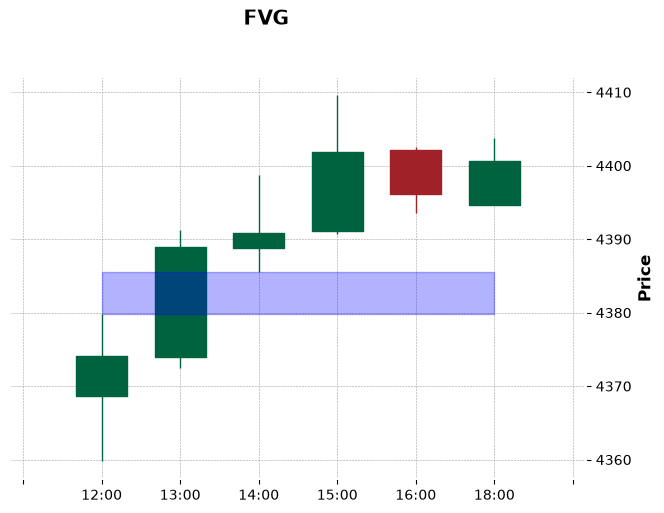

In [6]:
import mplfinance as mpf

if len(fvg_lista) == 0:
    print("Inga FVG hittades i den hämtade datan.")
else:
    i = min(2, len(fvg_lista) - 1)   # 3:e om det finns, annars det sista
    datum, gap_start, gap_end = fvg_lista[i]

    # Ta reda på vilket radnummer i tabellen "data" som det datumet har
    idx = data.index.get_loc(datum)

    # Klipp ut candles 2 innan och 4 efter det radnumret, för att rita dem
    short_data = data.iloc[max(0,idx-2):idx+4]

    # Bestäm vilket prisintervall som ska målas blått (själva FVG)
    fvg = dict(y1=float(gap_start.item()), y2=float(gap_end.item()), color='blue', alpha=0.3)

    # Rita candlestick-grafen med FVG markerat
    mpf.plot(short_data, type='candle', style='charles', fill_between=fvg, title='FVG',datetime_format='%H:%M', xrotation=0)